# 第 1 步「数据生成」验证 notebook

配套讲解文档：`../../simulation_tutorial.html` 第 1 节。

本 notebook 直接调用仓库里的真实代码（`train.py`），逐条验证我们讨论过的结论：

1. `A` 是 16×64、**行标准正交**（`A @ A.T = I_16`），所以 `M = A.T @ A` 是投影矩阵
2. `theta_1` 完全在子空间内（off-ratio = 0），`theta_2` off-ratio 精确 = 9
3. `generate_x` 采出的数据**严格落在 16 维子空间上**（off-ratio ≈ 0）
4. `UnitBallData` 采出的数据**严格落在单位球面上**（‖x‖ = 1）

> 提示：本 notebook 用 base anaconda python 测试通过。请用装好 `requirements.txt` 的内核运行。

In [1]:
# ---- 环境准备 ----
%matplotlib inline
import os, sys, types

# Windows 上 numpy/torch 各带一份 OpenMP，会冲突；这行是安全网（须在 import torch 前设置）
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# 定位 simulations 目录（本 notebook 就放在里面）
# 自动定位 simulations 目录（含 train.py），无论本 notebook 放在哪层文件夹
_here = os.getcwd()
_cands = [_here, os.path.dirname(_here),
          os.path.join(_here, "simulations"),
          os.path.join(os.path.dirname(_here), "simulations"),
          r"H:\My Drive\Research\DAM\code\GGDMOptim\simulations"]
SIM_DIR = next((c for c in _cands if os.path.exists(os.path.join(c, "train.py"))), _here)
os.chdir(SIM_DIR); sys.path.insert(0, SIM_DIR)

# train.py 顶部 import 了 tensorboard（只有训练 logger 用，数据生成用不到）。
# 若环境没装 tensorboard，就用一个空 SummaryWriter 占位，避免 import 失败。
try:
    import tensorboard  # noqa: F401
except ImportError:
    _fake = types.ModuleType("torch.utils.tensorboard")
    class _DummyWriter:
        def __init__(self, *a, **k): pass
        def add_scalar(self, *a, **k): pass
    _fake.SummaryWriter = _DummyWriter
    sys.modules["torch.utils.tensorboard"] = _fake

import numpy as np
import matplotlib.pyplot as plt
from train import LinearLatentData, UnitBallData, set_seed

# 让 matplotlib 能显示中文（Windows 自带 Microsoft YaHei / SimHei）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

set_seed(2345)
print("simulations dir:", SIM_DIR)

simulations dir: H:\My Drive\Research\DAM\code\GGDMOptim\simulations


## Part 1 · 读取 linear_latent 的 hyperparameters

`LinearLatentData(...)` 在父类 `BasicData.__init__` 里：文件存在就 `load_hyper` 读，不存在就 `generate_hyperparameters` 现造。
这里 `data/linear_latent/hyperparameters.npz` 已存在（论文冻结的参数），所以是**读**。

In [2]:
g = LinearLatentData(
    hyper_path="data/linear_latent/hyperparameters.npz",
    d_inner=16, d_outer=64, r_off=9,
)

print("d_inner =", int(g.d_inner), "| d_outer =", int(g.d_outer))
print("A.shape       =", g.A.shape, "  (16 x 64：16 个正交基行)")
print("theta_1.shape =", g.theta_1.shape)
print("theta_2.shape =", g.theta_2.shape)
print("b_1 =", g.b_1, " (标量 4，靠 broadcast 变成 4*1_D)")
print("b_2.shape =", np.atleast_1d(g.b_2).shape, " (每维 ~ N(4, 9))")

d_inner = 16 | d_outer = 64
A.shape       = (16, 64)   (16 x 64：16 个正交基行)
theta_1.shape = (64, 1)
theta_2.shape = (64, 1)
b_1 = 4.0  (标量 4，靠 broadcast 变成 4*1_D)
b_2.shape = (64,)  (每维 ~ N(4, 9))


## Part 2 · `A` 行正交 ⟹ `M = AᵀA` 是投影矩阵

- 行正交：`A @ A.T == I_16`（这是 `ortho_group` 保证的，所以投影不用求逆）
- 投影矩阵 `M = A.T @ A` 应满足：**对称** `Mᵀ=M`、**幂等** `M²=M`、**秩 = 16**

In [3]:
I16 = np.eye(16)
print("A @ A.T == I_16 ?", np.allclose(g.A @ g.A.T, I16, atol=1e-6))

M = g.A.T @ g.A          # 64 x 64 投影矩阵
print("M 对称  Mᵀ=M ?", np.allclose(M, M.T, atol=1e-6))
print("M 幂等  M²=M ?", np.allclose(M @ M, M, atol=1e-6))
print("M 的秩 =", int(np.linalg.matrix_rank(M)), "(应为 16)")
print("M 的迹 =", round(float(np.trace(M)), 4), "(= 秩 = 子空间维数 16)")

# 特征值应是 16 个 1 + 48 个 0（投影算子的标志）
eigvals = np.sort(np.linalg.eigvalsh(M))[::-1]
print("最大 18 个特征值:", np.round(eigvals[:18], 3))

A @ A.T == I_16 ? True
M 对称  Mᵀ=M ? True
M 幂等  M²=M ? True
M 的秩 = 16 (应为 16)
M 的迹 = 16.0 (= 秩 = 子空间维数 16)
最大 18 个特征值: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.]


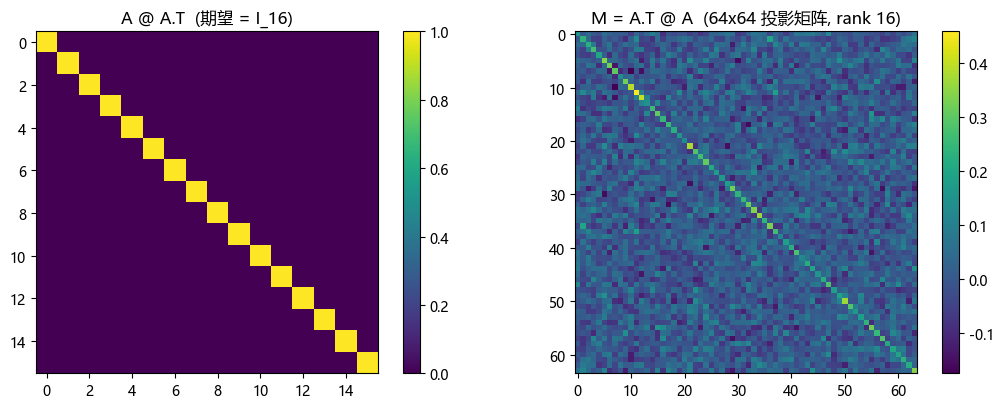

In [4]:
# 可视化：左 = A@A.T 应是 16x16 单位阵；右 = M=A.T@A 是 64x64 投影矩阵
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = ax[0].imshow(g.A @ g.A.T, cmap="viridis"); ax[0].set_title("A @ A.T  (期望 = I_16)")
fig.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(M, cmap="viridis"); ax[1].set_title("M = A.T @ A  (64x64 投影矩阵, rank 16)")
fig.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Part 3 · `theta_1`（on-support） vs `theta_2`（off-ratio = 9）

`off_support_ratio` 把向量拆成 子空间内分量 `parallel` 和 垂直分量 `vertical`，返回 `‖vertical‖ / ‖parallel‖`。

In [5]:
r1 = float(g.off_support_ratio(g.theta_1)[0])
r2 = float(g.off_support_ratio(g.theta_2)[0])
print(f"theta_1 off-ratio = {r1:.6f}   <- 完全在子空间内 (on-support)")
print(f"theta_2 off-ratio = {r2:.6f}   <- 精确等于 9 (大部分指向流形外)")

# 把 theta_2 拆开看两段长度：垂直段应是平行段的 9 倍
par, ver, _ = g.off_support_ratio(g.theta_2, return_components=True)
np_par, np_ver = np.linalg.norm(par), np.linalg.norm(ver)
print(f"\ntheta_2:  ‖parallel‖ = {np_par:.4f},  ‖vertical‖ = {np_ver:.4f},  比值 = {np_ver/np_par:.4f}")
print(f"theta_2 总范数 = {np.linalg.norm(g.theta_2):.4f}  (构造最后归一化过, 应≈1)")

theta_1 off-ratio = 0.000000   <- 完全在子空间内 (on-support)
theta_2 off-ratio = 8.999999   <- 精确等于 9 (大部分指向流形外)

theta_2:  ‖parallel‖ = 0.1104,  ‖vertical‖ = 0.9939,  比值 = 9.0000
theta_2 总范数 = 1.0000  (构造最后归一化过, 应≈1)


## Part 4 · `generate_x` 采出的数据落在子空间上

`x = randn(N,16) @ A`，是 16 个正交行的线性组合，所以**必然**在子空间内 → off-ratio ≈ 0（只剩浮点误差）。
和**纯随机高斯点**对比就能看出差别：随机点的 off-ratio 约为 √(48/16)=√3≈1.73。

In [6]:
N = 5000
x_data = g.generate_x(N)                 # 落在子空间上的"真实数据"
x_rand = np.random.randn(N, 64)          # 纯随机高斯点（作对照）

r_data = g.off_support_ratio(x_data)
r_rand = g.off_support_ratio(x_rand)

print(f"generate_x  : off-ratio  mean={r_data.mean():.3e}  max={r_data.max():.3e}   (≈0, 在流形上)")
print(f"随机高斯点  : off-ratio  mean={r_rand.mean():.3f}    max={r_rand.max():.3f}    (≈√3, 离流形远)")

generate_x  : off-ratio  mean=6.676e-16  max=1.226e-15   (≈0, 在流形上)
随机高斯点  : off-ratio  mean=1.804    max=4.095    (≈√3, 离流形远)


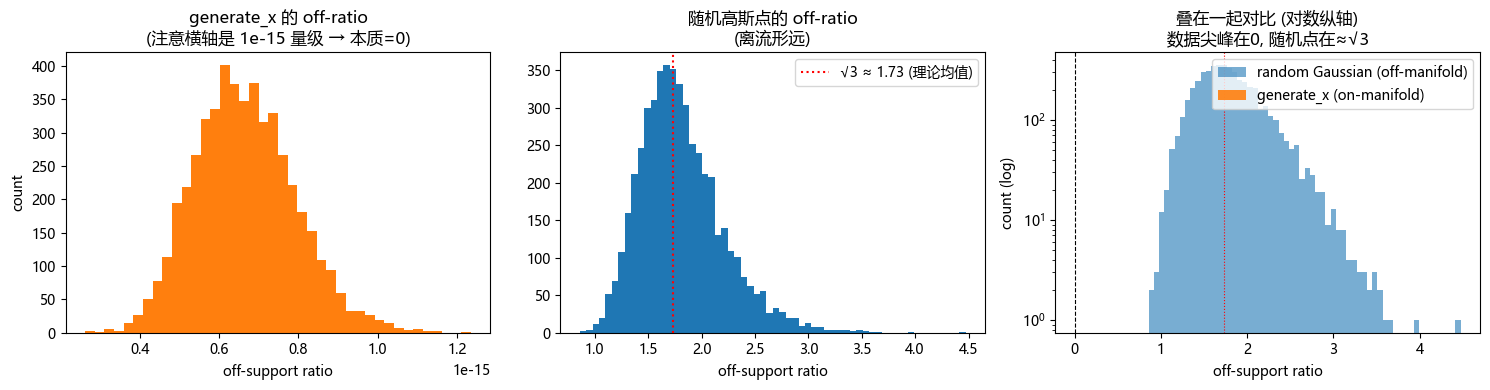

In [15]:
# 两组分布的尺度差异极大：x_data 全挤在 0（5000 个点堆成一根针），
# x_rand 摊在 1~4 之间（每个 bin 才几百）。
# 解决办法：左右两个子图各看各的形状；再叠一张对数纵轴图，直接对比"位置"。
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (左) generate_x：放大到 1e-15 量级，看到它其实只是浮点误差，本质就是 0
ax[0].hist(r_data, bins=40, color="tab:orange")
ax[0].set_title("generate_x 的 off-ratio\n(注意横轴是 1e-15 量级 → 本质=0)")
ax[0].set_xlabel("off-support ratio"); ax[0].set_ylabel("count")

# (中) 随机高斯点：明显的钟形，峰在 √3 附近
ax[1].hist(r_rand, bins=60, color="tab:blue")
ax[1].axvline(np.sqrt(3), color="r", ls=":", label="√3 ≈ 1.73 (理论均值)")
ax[1].set_title("随机高斯点的 off-ratio\n(离流形远)")
ax[1].set_xlabel("off-support ratio"); ax[1].legend()

# (右) 两者叠在同一横轴上，用对数纵轴，才能同时看见尖峰和钟形
ax[2].hist(r_rand, bins=60, alpha=0.6, label="random Gaussian (off-manifold)")
ax[2].hist(r_data, bins=60, alpha=0.9, label="generate_x (on-manifold)")
ax[2].set_yscale("log")                  # ★ 关键：对数纵轴，否则 0 处尖峰会把钟形压扁
ax[2].axvline(0, color="k", lw=0.8, ls="--")
ax[2].axvline(np.sqrt(3), color="r", lw=0.8, ls=":")
ax[2].set_title("叠在一起对比 (对数纵轴)\n数据尖峰在0, 随机点在≈√3")
ax[2].set_xlabel("off-support ratio"); ax[2].set_ylabel("count (log)"); ax[2].legend()

plt.tight_layout(); plt.show()

## Part 5 · 直观看到"数据是平的"

取一个**子空间内**方向（`A` 的第 0 行）和一个**垂直于子空间**方向，把样本分别投到这两个方向上做散点。
- 沿子空间方向：坐标有正常分布（数据在这个方向上有变化）
- 沿垂直方向：坐标恒为 0（数据在这个方向上**没有任何延展** → 流形是"平的"）

沿子空间方向坐标:  std = 1.000  (有延展)
沿垂直方向坐标:    std = 4.353e-16  (≈0, 没延展)


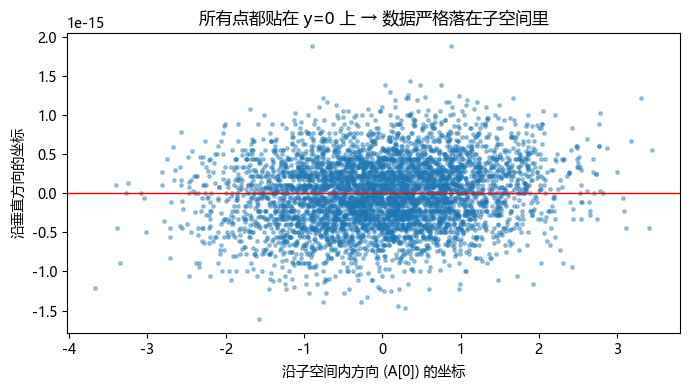

In [8]:
in_dir = g.A[0] / np.linalg.norm(g.A[0])            # 子空间内的单位方向

rv = np.random.randn(64)                              # 随机向量
rv_perp = rv - rv @ M                                 # 减掉它在子空间里的分量 → 纯垂直方向
off_dir = rv_perp / np.linalg.norm(rv_perp)

c_in  = x_data @ in_dir       # 样本沿"子空间内方向"的坐标
c_off = x_data @ off_dir      # 样本沿"垂直方向"的坐标

print(f"沿子空间方向坐标:  std = {c_in.std():.3f}  (有延展)")
print(f"沿垂直方向坐标:    std = {c_off.std():.3e}  (≈0, 没延展)")

plt.figure(figsize=(7, 4))
plt.scatter(c_in, c_off, s=6, alpha=0.4)
plt.axhline(0, color="r", lw=1)
plt.xlabel("沿子空间内方向 (A[0]) 的坐标"); plt.ylabel("沿垂直方向的坐标")
plt.title("所有点都贴在 y=0 上 → 数据严格落在子空间里"); plt.tight_layout(); plt.show()

## Part 6 · `UnitBallData`：非线性流形（单位球面）

对照看：这里流形是**弯的**球面 `‖x‖=1`，off-support 定义换成 `‖x‖ - 1`。
reward 是线性 `f(x)=θᵀx`，在球面上最优点就是 `x*=θ`（reward 最大 = 1）。

‖x‖   mean=1.000000  std=7.198e-17   (应≈1)
off   mean=-3.029e-17  max|off|=2.220e-16  (应≈0)

reward θᵀx :  min=-0.407  max=0.413  (理论上界=1, 在 x=θ 取到)


C:\Users\24405\AppData\Local\Temp\ipykernel_2124\3053688496.py:18: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  plt.tight_layout(); plt.show()


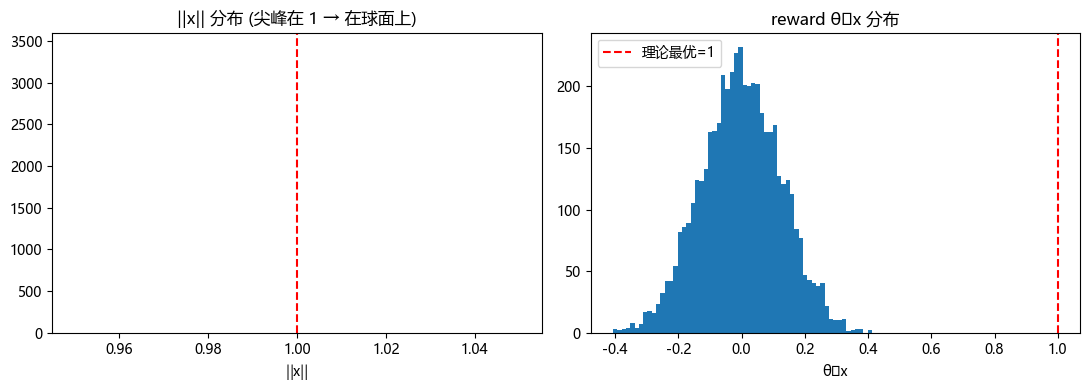

In [14]:
u = UnitBallData(hyper_path="data/unit_ball/hyperparameters.npz", d_outer=64)
xb = u.generate_x(5000)

norms = np.linalg.norm(xb, axis=-1)
off_b = u.off_support_ratio(xb)            # = ‖x‖ - 1
print(f"‖x‖   mean={norms.mean():.6f}  std={norms.std():.3e}   (应≈1)")
print(f"off   mean={off_b.mean():.3e}  max|off|={np.abs(off_b).max():.3e}  (应≈0)")

theta = u.theta.ravel()
rewards = xb @ theta                       # f(x)=θᵀx，范围 [-1,1]
print(f"\nreward θᵀx :  min={rewards.min():.3f}  max={rewards.max():.3f}  (理论上界=1, 在 x=θ 取到)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(norms, bins=60); ax[0].axvline(1, color="r", ls="--")
ax[0].set_title("‖x‖ 分布 (尖峰在 1 → 在球面上)"); ax[0].set_xlabel("‖x‖")
ax[1].hist(rewards, bins=60); ax[1].axvline(1, color="r", ls="--", label="理论最优=1")
ax[1].set_title("reward θᵀx 分布"); ax[1].set_xlabel("θᵀx"); ax[1].legend()
plt.tight_layout(); plt.show()

## 小结

| 验证项 | 结论 |
|---|---|
| `A @ A.T = I_16` | 行标准正交 ✓ |
| `M = A.T @ A` 对称/幂等/秩16 | 是子空间投影矩阵 ✓ |
| `theta_1` off-ratio | 0（on-support）✓ |
| `theta_2` off-ratio | 9（构造精确）✓ |
| `generate_x` off-ratio | ≈0（数据在 16 维子空间上）✓ |
| `UnitBallData` ‖x‖ | =1（数据在单位球面上）✓ |

**第 1 步「数据生成」完成。** 下一步进入第 2 步「加噪 forward process」——会用到这里的 `generate_x` 产出的数据 `x_0`，看它被一步步泡进噪声后变成什么样。